In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

os.chdir('../ts-rag')

def parse_result_file(file_path):
    results_dict = {}  # Use a dictionary to keep only the last result per dataset
    with open(file_path, 'r') as f:
        lines = f.readlines()
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if not line:
            i += 1
            continue
        if '_zeroshot_' in line:
            dataset = line.split('_zeroshot_')[0]
            if i + 1 < len(lines):
                metric_line = lines[i + 1].strip()
                mse_match = re.search(r'mse:([\d.]+)', metric_line)
                mae_match = re.search(r'mae:([\d.]+)', metric_line)
                if mse_match and mae_match:
                    # Update dictionary - later results will overwrite earlier ones
                    results_dict[dataset] = {
                        'dataset': dataset,
                        'mse': float(mse_match.group(1)),
                        'mae': float(mae_match.group(1))
                    }
                i += 2
            else:
                i += 1
        else:
            i += 1
    return pd.DataFrame(list(results_dict.values()))

In [2]:
PATH = f'results/forecast_evaluation'
settings = os.listdir(PATH)
setting_random_zeroshot = [x for x in settings if 'random.' in x]
setting_random_pretrain = [x for x in settings if 'random2.' in x]
os.chdir(PATH)

In [3]:
zeroshot_ours_df = []
zeroshot_base_df = []

pretrain_ours6_df = []
pretrain_ours7_df = []
pretrain_ours8_df = []
pretrain_base_df = []

K_list = [3,5,10,15,20]
# K_list = [3,5,15,20]

for k in K_list:
    setting_random_zeroshot_ = [x for x in setting_random_zeroshot if f'_k{k}_' in x]
    setting_random_zeroshot_base = [x for x in setting_random_zeroshot_ if 'dualhead' not in x]
    setting_random_zeroshot_ours = [x for x in setting_random_zeroshot_ if 'dualhead' in x]
    
    setting_random_pretrain_ = [x for x in setting_random_pretrain if f'_k{k}_' in x]
    setting_random_pretrain_base = [x for x in setting_random_pretrain_ if 'dualhead' not in x]
    setting_random_pretrain_ours = [x for x in setting_random_pretrain_ if 'dualhead' in x]
    
    setting_random_pretrain_ours1 = [x for x in setting_random_pretrain_ if '0.6' in x]    
    setting_random_pretrain_ours2 = [x for x in setting_random_pretrain_ if '0.7' in x]    
    setting_random_pretrain_ours3 = [x for x in setting_random_pretrain_ if '0.8' in x]    
    
#     assert len(setting_random_zeroshot_base)==1
#     assert len(setting_random_zeroshot_ours)==1
    assert len(setting_random_pretrain_base)==1
    assert len(setting_random_pretrain_ours1)==1
    assert len(setting_random_pretrain_ours2)==1
    assert len(setting_random_pretrain_ours3)==1
#     x = setting_random_zeroshot_base[0]
#     df = parse_result_file(x)
#     df_mse = df['mse']
#     datasets = df['dataset']
    
#     x = setting_random_zeroshot_ours[0]
#     df = parse_result_file(x)
#     df_mse = df['mse']
#     datasets = df['dataset']

    x = setting_random_pretrain_base[0]
    df = parse_result_file(x)
    df_mse = df['mse']
    datasets = df['dataset']
    pretrain_base_df.append(df_mse)

    
    x = setting_random_pretrain_ours1[0]
    df = parse_result_file(x)
    df_mse = df['mse']
    datasets = df['dataset']
    pretrain_ours6_df.append(df_mse)
    
    x = setting_random_pretrain_ours2[0]
    df = parse_result_file(x)
    df_mse = df['mse']
    datasets = df['dataset']
    pretrain_ours7_df.append(df_mse)
    
    x = setting_random_pretrain_ours3[0]
    df = parse_result_file(x)
    df_mse = df['mse']
    datasets = df['dataset']
    pretrain_ours8_df.append(df_mse)
    


In [4]:
pretrain_base_df = pd.concat(pretrain_base_df,axis=1)
pretrain_ours6_df = pd.concat(pretrain_ours6_df,axis=1)
pretrain_ours7_df = pd.concat(pretrain_ours7_df,axis=1)
pretrain_ours8_df = pd.concat(pretrain_ours8_df,axis=1)    
pretrain_base_df.columns = K_list
pretrain_base_df.index = datasets    
pretrain_ours6_df.columns = K_list
pretrain_ours6_df.index = datasets    
pretrain_ours7_df.columns = K_list
pretrain_ours7_df.index = datasets    
pretrain_ours8_df.columns = K_list
pretrain_ours8_df.index = datasets    

pretrain_base_df = pretrain_base_df.drop('electricity',axis=0)
pretrain_ours6_df = pretrain_ours6_df.drop('electricity',axis=0)
pretrain_ours7_df = pretrain_ours7_df.drop('electricity',axis=0)
pretrain_ours8_df = pretrain_ours8_df.drop('electricity',axis=0)

pretrain_base_df.loc['avg'] = pretrain_base_df.mean(axis=0)
pretrain_ours6_df.loc['avg'] = pretrain_ours6_df.mean(axis=0)
pretrain_ours7_df.loc['avg'] = pretrain_ours7_df.mean(axis=0)
pretrain_ours8_df.loc['avg'] = pretrain_ours8_df.mean(axis=0)

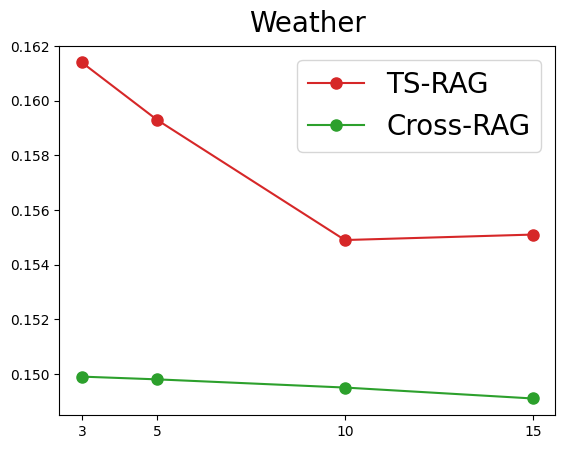

In [5]:
#pretrain_ours7_df
plt.plot(pretrain_base_df.loc[datasets[5]][:-1],label='TS-RAG',marker='o',markersize=8,color='tab:red')
plt.plot(pretrain_ours7_df.loc[datasets[5]][:-1],label='Cross-RAG',marker='o',markersize=8,color='tab:green')
plt.title('Weather',fontsize=20,pad=10)
plt.xticks([3,5,10,15])
plt.legend(fontsize=20,loc='upper right')

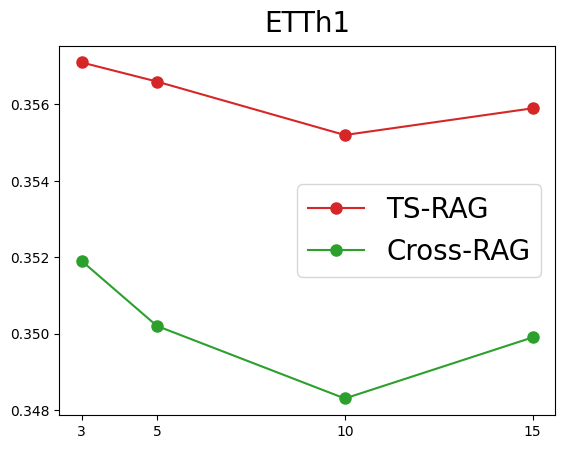

In [6]:
idx = 1
plt.plot(pretrain_base_df.loc[datasets[idx]][:-1],label='TS-RAG',marker='o',markersize=8,color='tab:red')
plt.plot(pretrain_ours8_df.loc[datasets[idx]][:-1],label='Cross-RAG',marker='o',markersize=8,color='tab:green')
plt.title('ETTh1',fontsize=20,pad=10)
plt.xticks([3,5,10,15])
plt.legend(fontsize=20)

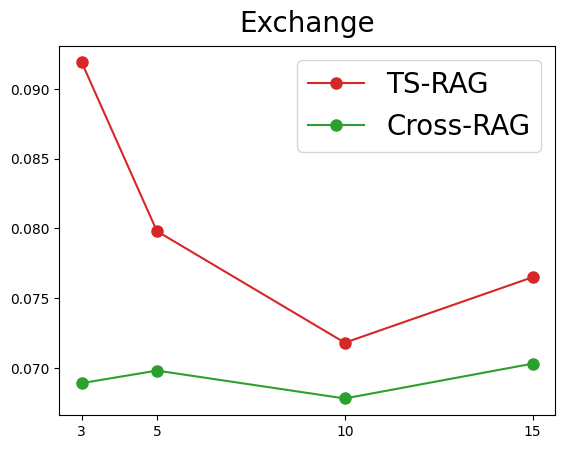

In [7]:
idx = 0
plt.plot(pretrain_base_df.loc[datasets[idx]][:-1],label='TS-RAG',marker='o',markersize=8,color='tab:red')
plt.plot(pretrain_ours7_df.loc[datasets[idx]][:-1],label='Cross-RAG',marker='o',markersize=8,color='tab:green')
plt.title('Exchange',fontsize=20,pad=10)
plt.xticks([3,5,10,15])
plt.legend(fontsize=20,loc='upper right')

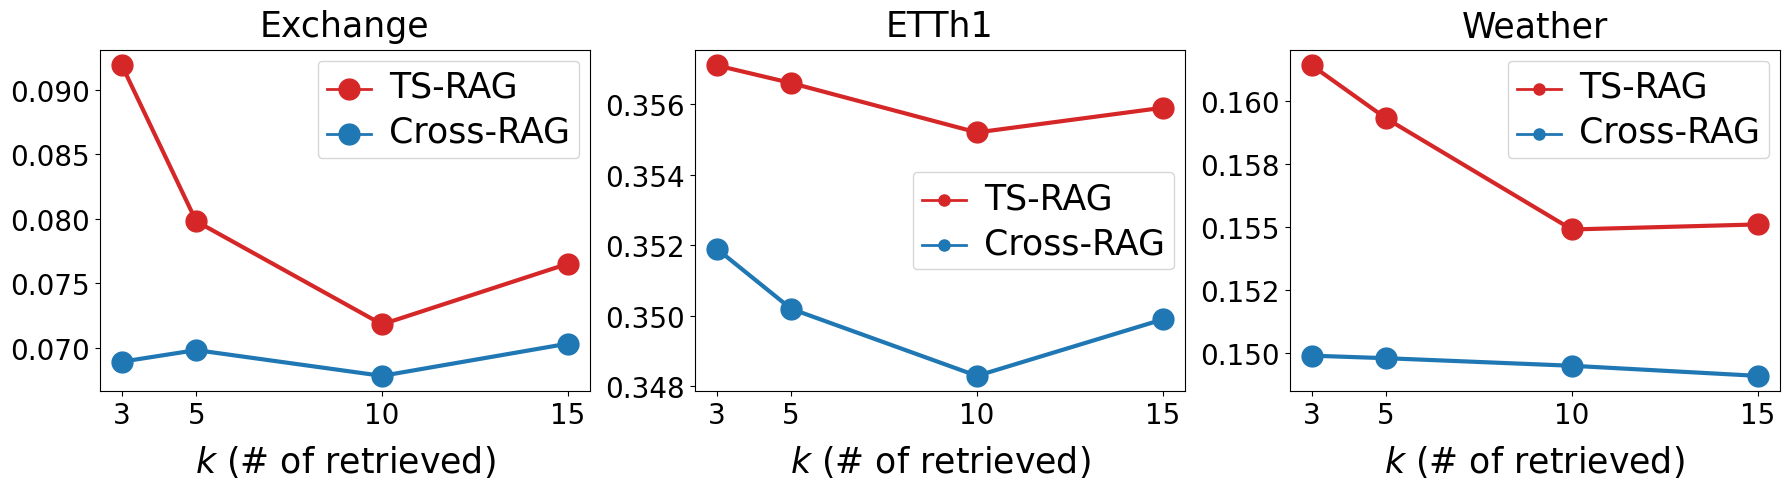

In [16]:
# Plot styling function
def configure_plot_style(fig, ax, 
                         xtick_size=14, ytick_size=14,
                         xlabel_size=16, ylabel_size=16,
                         title_size=20, legend_size=16,
                         marker_size=8, linewidth=2,
                         title_pad=10, label_pad=10,
                         fig_padding=0.5,
                         ytick_format='{:.3f}'):
    """
    Configure plot styling parameters
    
    Parameters:
    -----------
    fig : matplotlib.figure.Figure
        Figure object
    ax : matplotlib.axes.Axes or array of Axes
        Axes object(s) to configure
    xtick_size : int
        Size of x-axis tick labels
    ytick_size : int
        Size of y-axis tick labels
    xlabel_size : int
        Size of x-axis label
    ylabel_size : int
        Size of y-axis label
    title_size : int
        Size of title
    legend_size : int
        Size of legend text
    marker_size : int
        Size of markers
    linewidth : float
        Width of lines
    title_pad : float
        Padding for title
    label_pad : float
        Padding for labels
    fig_padding : float
        Padding around figure
    ytick_format : str
        Format string for y-axis tick labels (e.g., '{:.3f}' for 3 decimal places)
    """
    if isinstance(ax, np.ndarray):
        axes = ax.flat
    else:
        axes = [ax]
    
    for ax_item in axes:
        ax_item.tick_params(axis='x', labelsize=xtick_size)
        ax_item.tick_params(axis='y', labelsize=ytick_size)
        
        # Format y-axis ticks
        if ytick_format:
            ax_item.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: ytick_format.format(x)))
        
        if ax_item.get_xlabel():
            ax_item.set_xlabel(ax_item.get_xlabel(), fontsize=xlabel_size, labelpad=label_pad)
        if ax_item.get_ylabel():
            ax_item.set_ylabel(ax_item.get_ylabel(), fontsize=ylabel_size, labelpad=label_pad)
        if ax_item.get_title():
            ax_item.set_title(ax_item.get_title(), fontsize=title_size, pad=title_pad)
        legend = ax_item.get_legend()
        if legend:
            for text in legend.get_texts():
                text.set_fontsize(legend_size)
        # Update line and marker sizes in the plot
        for line in ax_item.get_lines():
            line.set_markersize(marker_size)
            line.set_linewidth(linewidth)
    
    plt.tight_layout(pad=fig_padding)
    return fig, ax

# Create 1x3 subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Exchange (Cell 6 - idx=0)
idx = 0
axes[0].plot(pretrain_base_df.loc[datasets[idx]][:-1], label='TS-RAG', marker='o', markersize=15, color='tab:red', linewidth=2)
axes[0].plot(pretrain_ours7_df.loc[datasets[idx]][:-1], label='Cross-RAG', marker='o', markersize=15, color='tab:blue', linewidth=2)
axes[0].set_title('Exchange', fontsize=20, pad=10)
axes[0].set_xticks([3, 5, 10, 15])
axes[0].set_xlabel(r'$k$ (# of retrieved)')
axes[0].legend(fontsize=16, loc='upper right')

# Plot 2: ETTh1 (Cell 5 - idx=1)
idx = 1
axes[1].plot(pretrain_base_df.loc[datasets[idx]][:-1], label='TS-RAG', marker='o', markersize=8, color='tab:red', linewidth=2)
axes[1].plot(pretrain_ours8_df.loc[datasets[idx]][:-1], label='Cross-RAG', marker='o', markersize=8, color='tab:blue', linewidth=2)
axes[1].set_title('ETTh1', fontsize=20, pad=10)
axes[1].set_xticks([3, 5, 10, 15])
axes[1].set_xlabel(r'$k$ (# of retrieved)')
axes[1].legend(fontsize=16)

# Plot 3: Weather (Cell 4 - datasets[5])
axes[2].plot(pretrain_base_df.loc[datasets[5]][:-1], label='TS-RAG', marker='o', markersize=8, color='tab:red', linewidth=2)
axes[2].plot(pretrain_ours7_df.loc[datasets[5]][:-1], label='Cross-RAG', marker='o', markersize=8, color='tab:blue', linewidth=2)
axes[2].set_title('Weather', fontsize=20, pad=10)
axes[2].set_xticks([3, 5, 10, 15])
axes[2].set_xlabel(r'$k$ (# of retrieved)')
axes[2].legend(fontsize=16, loc='upper right')

# Apply styling
fig, axes = configure_plot_style(
    fig, axes,
    xtick_size=20, ytick_size=20,
    xlabel_size=25, ylabel_size=16,
    title_size=25, legend_size=25,
    marker_size=15, linewidth=3,
    title_pad=10, label_pad=10,
    fig_padding=0.5,
    ytick_format='{:.3f}'  # Format y-axis ticks to 3 decimal places
)

#plt.show()
plt.tight_layout()
SAVE_PATH = '/home/seunghan.lee/workspace/experiments/figures'
fn = "random_retrieval.pdf"
fn = os.path.join(SAVE_PATH,fn)
plt.savefig(fn, bbox_inches="tight")
plt.show()
